Steerable-CNN + Neural-Amplitude-Encoding + Equivariant-QCNN for DeepLense
============================================================================

Pipeline (the "Scenario B" upgrade over the QVF MLP):

  lensing image (B,1,H,W)
    -> C8 / D8 steerable CNN            (e2cnn)            -> equivariant feature maps
    -> GroupPooling + global avg pool                      -> rotation-INVARIANT vector
    -> Linear -> sqrt(softmax(.))       (QVF trick)        -> 256 real amplitudes (||.||2 = 1)
    -> AmplitudeEmbedding into 8 qubits
    -> p4m EQUIVARIANT QCNN (U2_equiv + Pooling_ansatz_equiv, 33 params)   [EQNN_for_HEP]
    -> <Z> on all 8 wires -> Linear head -> logits (num_classes)

Components reused (as requested):
  * Steerable CNN building blocks ........ GSoC-23/models/C8SteerableCNN.py
  * Equivariant quantum circuit .......... EQNN_for_HEP/Equivariant_QCNN/models (U2_equiv / pooling / p4m structure),
                                           ported to TorchQuantum exactly as in frozen_quantum_model_1.ipynb
  * Neural amplitude encoding ............ Quantum-Visual-Fields-with-Neural-Amplitude-Encoding (softmax -> sqrt)
  * .npy lensing dataset + paths ......... frozen_quantum_model_2.ipynb

Quantum backend: TorchQuantum (tq.QuantumDevice + tq.MeasureAll). The 33-param p4m circuit is
expressed with native batched gates (rx/ry/rz/cnot/crx) so it runs fast on GPU with autograd.

Why this is a good fit for gravitational lensing:
  Lensing images have no preferred orientation, so the *label* is rotation-invariant.
  The steerable CNN bakes that symmetry into the weights (better sample efficiency, fewer params),
  then the QVF trick turns the learned invariant features into a valid quantum statevector that the
  equivariant QCNN mixes with only 33 quantum parameters.

NOTE: the steerable front-end already produces rotation-invariant features, so the QCNN's
      p4m-equivariance is not adding extra symmetry here -- it is acting as a compact, trainable
      quantum mixer. (Full end-to-end equivariance "into the amplitudes" is the separate
      strict-equivariance experiment where softmax/sqrt must be replaced.)

Security note (codeguard-1-hardcoded-credentials): this file contains NO secrets, API keys,
  tokens, or credentials. The dataset paths below are filesystem locations, not credentials,
  and are overridable via environment variables.

Requirements: torch, e2cnn, torchquantum, numpy, scikit-learn, matplotlib, tqdm
  pip install torchquantum e2cnn scikit-learn matplotlib tqdm
============================================================================

In [1]:
# ---- Cell 1: Imports ----
import os
import time
import json
import random
import collections
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF

import torchquantum as tq
from e2cnn import gspaces
from e2cnn import nn as e2nn

import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report, f1_score
from sklearn.preprocessing import label_binarize

torch.manual_seed(42)
np.random.seed(42)

# GPU perf knobs (free speedup for the steerable-CNN front-end; no behavior change for this task).
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    try:
        torch.set_float32_matmul_precision("high")
    except Exception:
        pass

print(f"PyTorch version: {torch.__version__}")
print(f"TorchQuantum version: {tq.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

PyTorch version: 2.5.1+cu124
TorchQuantum version: 0.1.8
CUDA available: True


In [2]:
# ---- Cell 2: Config (dataset paths reused from frozen_quantum_model_1.ipynb) ----

# Quantum / encoding
N_QUBITS = 8                       # 8 qubits -> 2**8 = 256 amplitudes
AMP_DIM = 2 ** N_QUBITS            # 256 neural amplitudes produced by the steerable encoder

# Encoding selector: set ONE; the encoder + quantum core adapt automatically.
#   "amplitude" -> QVF neural amplitude encoding (256-dim statevector, most "quantum")
#   "angle"     -> neural angle encoding (8 tanh-bounded RY angles, equiqnn-style, easiest)
#   "reupload"  -> angle encoding re-uploaded across REUPLOAD_LAYERS blocks (more quantum work)
ENCODING = "angle"
REUPLOAD_LAYERS = 2               # number of data re-uploads (only used when ENCODING == "reupload")

# Steerable CNN
GROUP_N = 4                        # 4 discrete rotations (C4); matches equiqnn, ~2x faster than C8
USE_REFLECTIONS = False            # False -> C8 (rotations only); True -> D8 (rotations + mirrors)
BASE_WIDTH = 8                     # regular-rep fields in block1 (block2 = 2x, block3 = 4x). Bump to 16 for more capacity.
SOFTMAX_TEMPERATURE = 1.0          # QVF "Boltzmann" temperature for the amplitude softmax
ENCODER_DROPOUT = 0.3              # dropout in the amplitude head (anti-overfitting)

# Quantum readout: <Z> on all 8 wires only (matches equiqnn model_1's MeasureAll(PauliZ)).
READOUT_PAULIS = ("Z",)            # single-qubit observable measured per wire
READOUT_ZZ = False                 # no <Z_i Z_j> correlators

# Hybrid residual disabled: classification goes solely through the 8-dim quantum readout
# (matches equiqnn model_1). Kept as a flag for parity with the other encodings' notebooks.
HYBRID_RESIDUAL = False
RESIDUAL_DIM = 16

# Augmentation (train only; lensing labels are rotation/reflection invariant -> label-preserving)
AUGMENT = True
AUG_MAX_ROTATION = 15.0            # degrees
AUG_MAX_TRANSLATE = 0.1            # fraction of image size

# Training
LOAD_IMG_SIZE = 150                # match the equiqnn 150x150 input; encoder pools internally
step = 1e-3
weight_decay = 1e-5                # match equiqnn model_1
batch_size = 64
num_epochs = 50
patience = 12
WARMUP_EPOCHS = 5                  # warmup + cosine LR schedule, matching equiqnn model_1

# Speed: torch.compile emits fused Triton kernels on CUDA. e2cnn + torchquantum will
# graph-break and fall back to eager (that's fine and expected); the classical head and
# pointwise ops still get fused. Set DEEPLENSE_COMPILE=0 to disable. Does NOT change the math.
USE_COMPILE = os.environ.get("DEEPLENSE_COMPILE", "1") != "0"

# Data
in_channels = 1
num_classes = 3

NOTEBOOK_NAME = "steerable_qvf_angle"
DATASET_ID = os.environ.get("DEEPLENSE_DATASET_ID", "model_2")


def slugify(value):
    value = str(value).strip().lower()
    slug = "".join(ch if ch.isalnum() else "_" for ch in value)
    return "_".join(part for part in slug.split("_") if part) or "model_2"


DATASET_ID = slugify(DATASET_ID)
VALID_DATASET_IDS = {f"model_{i}" for i in range(1, 5)}
if DATASET_ID not in VALID_DATASET_IDS:
    raise ValueError(f"DATASET_ID must be one of {sorted(VALID_DATASET_IDS)}, got {DATASET_ID!r}")

# Same dataset layout used by the EQNN-for-HEP lensing notebooks.
DATASET_ROOTS = {
    "model_1": "/home/jovyan/ssh-test-datavol-1/dataset/Model_I",
    "model_2": "/home/jovyan/ssh-test-datavol-1/dataset/Model_II",
    "model_3": "/home/jovyan/ssh-test-datavol-1/dataset/Model_III",
    "model_4": "/home/jovyan/ssh-test-datavol-1/dataset/Model_IV",
}
TEST_ROOTS = {
    "model_1": "/home/jovyan/ssh-test-datavol-1/dataset/Model_I_test",
    "model_2": "/home/jovyan/ssh-test-datavol-1/dataset/Model_II_test",
    "model_3": "/home/jovyan/ssh-test-datavol-1/dataset/Model_III_test",
    "model_4": "/home/jovyan/ssh-test-datavol-1/dataset/Model_IV_test",
}
DATA_ROOT = os.environ.get("DEEPLENSE_DATA_ROOT", DATASET_ROOTS[DATASET_ID])
TEST_DIR = os.environ.get("DEEPLENSE_TEST_DIR", TEST_ROOTS[DATASET_ID])
VAL_SPLIT = float(os.environ.get("DEEPLENSE_VAL_SPLIT", "0.20"))

CACHE_DATA_IN_MEMORY = os.environ.get("DEEPLENSE_CACHE_DATA", "1") != "0"
NUM_WORKERS = int(os.environ.get("DEEPLENSE_NUM_WORKERS", str(min(4, os.cpu_count() or 0))))
PREFETCH_FACTOR = int(os.environ.get("DEEPLENSE_PREFETCH_FACTOR", "4"))
PIN_MEMORY = torch.cuda.is_available()

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

RUN_DIR = Path.cwd() / DATASET_ID
RESULTS_DIR = RUN_DIR / "results"
CHECKPOINT_DIR = RUN_DIR / "checkpoints"
CHECKPOINT_PATH = CHECKPOINT_DIR / f"best_{NOTEBOOK_NAME}_{DATASET_ID}.pth"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

print(f"DATA_ROOT: {DATA_ROOT}")
print(f"TEST_DIR:  {TEST_DIR}")
print(f"Group: {'D' if USE_REFLECTIONS else 'C'}{GROUP_N} | qubits: {N_QUBITS} | amplitudes: {AMP_DIM} | classes: {num_classes}")
print(f"Device: {device}")

DATA_ROOT: /home/jovyan/ssh-test-datavol-1/dataset/Model_II
TEST_DIR:  /home/jovyan/ssh-test-datavol-1/dataset/Model_II_test
Group: C4 | qubits: 8 | amplitudes: 256 | classes: 3
Device: cuda:0


In [3]:
# ---- Cell 3: Dataset (the exact .npy lensing loader from frozen_quantum_model_2.ipynb) ----

IMAGE_KEYS = ("image", "img", "x", "data", "array", "arr", "lens", "sample")


def extract_image_array(value):
    """Return the image array from raw .npy content, including object arrays."""
    if isinstance(value, np.ndarray):
        if value.dtype == object:
            if value.ndim == 0:
                return extract_image_array(value.item())
            for item in value.reshape(-1):
                try:
                    candidate = extract_image_array(item)
                    if np.asarray(candidate).ndim >= 2:
                        return candidate
                except Exception:
                    continue
            return np.asarray(value.tolist())
        return value

    if isinstance(value, dict):
        for key in IMAGE_KEYS:
            if key in value:
                return extract_image_array(value[key])
        for item in value.values():
            try:
                candidate = extract_image_array(item)
                if np.asarray(candidate).ndim >= 2:
                    return candidate
            except Exception:
                continue
        raise ValueError("Could not find an image-like array in .npy dict")

    if isinstance(value, (list, tuple)):
        for item in value:
            try:
                candidate = extract_image_array(item)
                if np.asarray(candidate).ndim >= 2:
                    return candidate
            except Exception:
                continue
        return np.asarray(value)

    return np.asarray(value)


def load_npy_image(filepath):
    raw = np.load(filepath, allow_pickle=True)
    arr = np.asarray(extract_image_array(raw))
    if arr.dtype == object:
        arr = np.asarray(extract_image_array(arr), dtype=np.float32)
    else:
        arr = arr.astype(np.float32, copy=False)

    arr = np.squeeze(arr)
    if arr.ndim == 2:
        arr = arr[np.newaxis, :, :]
    elif arr.ndim == 3:
        if arr.shape[0] not in (1, 3):
            arr = arr.transpose(2, 0, 1)
    else:
        raise ValueError(f"Expected a 2D or 3D image array from {filepath}, got shape {arr.shape}")

    if arr.size == 0:
        raise ValueError(f"Empty image array in {filepath}")

    arr = np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0)
    arr_max = float(np.max(arr))
    if arr_max > 1.0:
        arr = arr / arr_max
    return arr.astype(np.float32, copy=False)


class NPYImageFolder(Dataset):
    """Dataset loader for .npy image files organized in class folders."""

    def __init__(self, root_dir, transform=None, samples=None, classes=None, class_to_idx=None, cache=False):
        self.root_dir = str(root_dir)
        self.transform = transform
        self.cache = None
        if not os.path.isdir(self.root_dir):
            raise FileNotFoundError(f"Dataset directory not found: {self.root_dir}")

        self.classes = list(classes) if classes is not None else sorted(
            d for d in os.listdir(self.root_dir)
            if os.path.isdir(os.path.join(self.root_dir, d))
        )
        self.class_to_idx = dict(class_to_idx) if class_to_idx is not None else {
            cls: idx for idx, cls in enumerate(self.classes)
        }

        if samples is None:
            self.samples = []
            for class_name in self.classes:
                class_dir = os.path.join(self.root_dir, class_name)
                for filename in sorted(os.listdir(class_dir)):
                    if filename.endswith(".npy"):
                        filepath = os.path.join(class_dir, filename)
                        self.samples.append((filepath, self.class_to_idx[class_name]))
        else:
            self.samples = list(samples)

        if not self.samples:
            raise RuntimeError(f"No .npy files found under {self.root_dir}")

        self.labels = torch.tensor([label for _, label in self.samples], dtype=torch.long)

        print(f"Found {len(self.samples)} samples in {self.root_dir}")
        print(f"Classes: {self.classes}")

        if cache:
            desc = f"cache {Path(self.root_dir).name}"
            print(f"Caching {len(self.samples)} decoded samples from {self.root_dir} in RAM...")
            self.cache = [
                torch.from_numpy(np.ascontiguousarray(load_npy_image(filepath))).float()
                for filepath, _ in tqdm(self.samples, desc=desc, leave=False)
            ]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        filepath, label = self.samples[idx]
        if self.cache is None:
            arr = load_npy_image(filepath)
            tensor = torch.from_numpy(np.ascontiguousarray(arr)).float()
        else:
            tensor = self.cache[idx]

        if self.transform:
            tensor = self.transform(tensor)

        return tensor, label


class NPYTransform:
    """Resize and channel-match NPY tensors."""

    def __init__(self, img_size, in_channels=1):
        self.img_size = img_size
        self.in_channels = in_channels

    def __call__(self, x):
        if x.shape[0] == 1 and self.in_channels == 3:
            x = x.repeat(3, 1, 1)
        elif x.shape[0] == 3 and self.in_channels == 1:
            x = x.mean(dim=0, keepdim=True)
        elif x.shape[0] != self.in_channels:
            x = x[:self.in_channels]

        if x.shape[-1] != self.img_size or x.shape[-2] != self.img_size:
            x = F.interpolate(
                x.unsqueeze(0), size=(self.img_size, self.img_size),
                mode="bilinear", align_corners=False,
            ).squeeze(0)
        return x


class NPYAugment:
    """Train-only augmentation matching equiqnn model_1's NPYTransform(augment=True).

    Strong-lensing class labels are invariant to flips and 90-degree rotations, so all of
    these are label-preserving and act purely as a regularizer against the fast train/val
    overfitting. Uses lossless rot90 (no resampling blur) + flips + Gaussian noise +
    brightness jitter, and NO translation (keeps the lens centred for the flatten-based head).
    """

    def __init__(self, img_size, in_channels=1, max_rotation=15.0, max_translate=0.1):
        self.base = NPYTransform(img_size, in_channels=in_channels)
        self.img_size = img_size

    def __call__(self, x):
        x = self.base(x)                                   # (C, S, S) in [0, 1]
        if torch.rand(1) > 0.5:
            k = torch.randint(0, 4, (1,)).item()
            if k > 0:
                x = torch.rot90(x, k, dims=[-2, -1])       # exact 90-degree rotations
        if torch.rand(1) > 0.5:
            x = torch.flip(x, dims=[-1])                   # horizontal flip
        if torch.rand(1) > 0.5:
            x = torch.flip(x, dims=[-2])                   # vertical flip
        if torch.rand(1) > 0.7:
            noise_std = torch.rand(1).item() * 0.03
            x = torch.clamp(x + torch.randn_like(x) * noise_std, 0, 1)
        if torch.rand(1) > 0.7:
            bf = 0.8 + torch.rand(1).item() * 0.4
            x = torch.clamp(x * bf, 0, 1)
        return x


def stratified_train_val_samples(samples, val_split=0.20, seed=42):
    """Split a single class-folder dataset into train/val while preserving each class."""
    labels = np.array([label for _, label in samples])
    rng = np.random.default_rng(seed)
    train_indices, val_indices = [], []
    for class_id in sorted(np.unique(labels).tolist()):
        class_indices = np.where(labels == class_id)[0]
        rng.shuffle(class_indices)
        if len(class_indices) <= 1:
            n_val = 0
        else:
            n_val = max(1, int(round(len(class_indices) * val_split)))
            n_val = min(n_val, len(class_indices) - 1)
        val_indices.extend(class_indices[:n_val].tolist())
        train_indices.extend(class_indices[n_val:].tolist())
    rng.shuffle(train_indices)
    rng.shuffle(val_indices)
    train_samples = [samples[i] for i in train_indices]
    val_samples = [samples[i] for i in val_indices]
    if not train_samples or not val_samples:
        raise ValueError("Train/val split is empty. Check VAL_SPLIT and per-class sample counts.")
    return train_samples, val_samples


def make_dataloader(dataset, batch_size, shuffle):
    kwargs = {
        "batch_size": batch_size,
        "shuffle": shuffle,
        "num_workers": NUM_WORKERS,
        "pin_memory": PIN_MEMORY,
    }
    if NUM_WORKERS > 0:
        kwargs["persistent_workers"] = True
        kwargs["prefetch_factor"] = PREFETCH_FACTOR
    return DataLoader(dataset, **kwargs)


def build_loaders(data_root, test_dir, img_size, batch_size, in_channels, val_split=0.20, seed=42):
    t0 = time.time()
    transform = NPYTransform(img_size, in_channels=in_channels)            # val / test (deterministic)
    if AUGMENT:
        train_transform = NPYAugment(
            img_size, in_channels=in_channels,
            max_rotation=AUG_MAX_ROTATION, max_translate=AUG_MAX_TRANSLATE,
        )
    else:
        train_transform = transform
    cache_data = CACHE_DATA_IN_MEMORY

    full_dataset = NPYImageFolder(data_root, transform=None, cache=False)
    train_samples, val_samples = stratified_train_val_samples(
        full_dataset.samples, val_split=val_split, seed=seed
    )
    train_set = NPYImageFolder(
        data_root, train_transform, samples=train_samples,
        classes=full_dataset.classes, class_to_idx=full_dataset.class_to_idx, cache=cache_data,
    )
    val_set = NPYImageFolder(
        data_root, transform, samples=val_samples,
        classes=full_dataset.classes, class_to_idx=full_dataset.class_to_idx, cache=cache_data,
    )
    test_set = NPYImageFolder(test_dir, transform, cache=cache_data)

    if test_set.classes != full_dataset.classes:
        raise ValueError(
            f"Class folders differ between DATA_ROOT and TEST_DIR: "
            f"{full_dataset.classes} vs {test_set.classes}"
        )

    train_loader = make_dataloader(train_set, batch_size=batch_size, shuffle=True)
    val_loader = make_dataloader(val_set, batch_size=batch_size, shuffle=False)
    test_loader = make_dataloader(test_set, batch_size=batch_size, shuffle=False)

    counts = collections.Counter(train_set.labels.tolist())
    print(f"Loader build took {time.time() - t0:.1f}s")
    print(f"Sizes: train={len(train_set)} val={len(val_set)} test={len(test_set)}")
    print("Class counts (train):", {full_dataset.classes[k]: v for k, v in sorted(counts.items())})
    return train_loader, val_loader, test_loader, full_dataset.classes


train_loader, val_loader, test_loader, class_names = build_loaders(
    DATA_ROOT, TEST_DIR, img_size=LOAD_IMG_SIZE, batch_size=batch_size,
    in_channels=in_channels, val_split=VAL_SPLIT,
)
num_classes = len(class_names)
print("Classes:", class_names)

Found 89104 samples in /home/jovyan/ssh-test-datavol-1/dataset/Model_II
Classes: ['axion', 'cdm', 'no_sub']
Found 71283 samples in /home/jovyan/ssh-test-datavol-1/dataset/Model_II
Classes: ['axion', 'cdm', 'no_sub']
Caching 71283 decoded samples from /home/jovyan/ssh-test-datavol-1/dataset/Model_II in RAM...


Found 17821 samples in /home/jovyan/ssh-test-datavol-1/dataset/Model_II
Classes: ['axion', 'cdm', 'no_sub']
Caching 17821 decoded samples from /home/jovyan/ssh-test-datavol-1/dataset/Model_II in RAM...


Found 15000 samples in /home/jovyan/ssh-test-datavol-1/dataset/Model_II_test
Classes: ['axion', 'cdm', 'no_sub']
Caching 15000 decoded samples from /home/jovyan/ssh-test-datavol-1/dataset/Model_II_test in RAM...


Loader build took 275.5s
Sizes: train=71283 val=17821 test=15000
Class counts (train): {'axion': 23917, 'cdm': 23807, 'no_sub': 23559}
Classes: ['axion', 'cdm', 'no_sub']


In [4]:
# ---- Cell 4: Steerable C8/D8 encoder + QVF neural amplitude encoding ----
#
# Building blocks mirror GSoC-23/models/C8SteerableCNN.py (e2cnn R2Conv / InnerBatchNorm /
# ReLU / PointwiseAvgPoolAntialiased / GroupPooling), generalized to N rotations (+ optional
# reflections) and ending in the QVF amplitude head: Linear -> softmax -> sqrt.

class SteerableAmplitudeEncoder(nn.Module):
    """Rotation-equivariant CNN -> invariant vector -> quantum input.

    Depending on `encoding`, the head emits either:
      - "amplitude": a 2**n_qubits statevector (softmax -> sqrt, ||a||_2 = 1),
      - "angle":     n_qubits tanh-bounded rotation angles,
      - "reupload":  reupload_layers * n_qubits tanh-bounded angles, shaped (B, L, n_qubits).
    """

    def __init__(self, img_size=64, in_channels=1, N=8, reflections=False,
                 n_qubits=8, base_width=8, temperature=1.0, dropout=0.3,
                 encoding="amplitude", reupload_layers=2):
        super().__init__()
        self.encoding = encoding
        self.n_qubits = n_qubits
        self.reupload_layers = reupload_layers
        self.temperature = temperature

        if encoding == "amplitude":
            out_dim = 2 ** n_qubits            # 256 amplitudes
        elif encoding == "angle":
            out_dim = n_qubits                 # one RY angle per qubit
        elif encoding == "reupload":
            out_dim = reupload_layers * n_qubits   # L re-uploaded angle sets
        else:
            raise ValueError(f"Unknown encoding {encoding!r}")
        self.out_dim = out_dim

        # Symmetry group: C_N (rotations) or D_N (rotations + mirrors).
        self.r2_act = gspaces.FlipRot2dOnR2(N=N) if reflections else gspaces.Rot2dOnR2(N=N)

        in_type = e2nn.FieldType(self.r2_act, in_channels * [self.r2_act.trivial_repr])
        self.input_type = in_type

        # 6-block / 3-pool steerable stack, matching equiqnn's C8SteerableCNN_Features depth
        # (widths 24/48/48/96/96/64 regular fields; kernels 7/5/5/5/5/5; pools after blocks 2/4/6).
        # block1: lift trivial input -> regular-rep feature fields
        out_type = e2nn.FieldType(self.r2_act, 24 * [self.r2_act.regular_repr])
        self.block1 = e2nn.SequentialModule(
            e2nn.MaskModule(in_type, img_size, margin=1),          # disk mask: clean boundary equivariance
            e2nn.R2Conv(in_type, out_type, kernel_size=7, padding=1, bias=False),
            e2nn.InnerBatchNorm(out_type),
            e2nn.ReLU(out_type, inplace=True),
        )

        in_type = out_type
        out_type = e2nn.FieldType(self.r2_act, 48 * [self.r2_act.regular_repr])
        self.block2 = e2nn.SequentialModule(
            e2nn.R2Conv(in_type, out_type, kernel_size=5, padding=2, bias=False),
            e2nn.InnerBatchNorm(out_type),
            e2nn.ReLU(out_type, inplace=True),
        )
        self.pool1 = e2nn.PointwiseAvgPoolAntialiased(out_type, sigma=0.66, stride=2)

        in_type = out_type
        out_type = e2nn.FieldType(self.r2_act, 48 * [self.r2_act.regular_repr])
        self.block3 = e2nn.SequentialModule(
            e2nn.R2Conv(in_type, out_type, kernel_size=5, padding=2, bias=False),
            e2nn.InnerBatchNorm(out_type),
            e2nn.ReLU(out_type, inplace=True),
        )

        in_type = out_type
        out_type = e2nn.FieldType(self.r2_act, 96 * [self.r2_act.regular_repr])
        self.block4 = e2nn.SequentialModule(
            e2nn.R2Conv(in_type, out_type, kernel_size=5, padding=2, bias=False),
            e2nn.InnerBatchNorm(out_type),
            e2nn.ReLU(out_type, inplace=True),
        )
        self.pool2 = e2nn.PointwiseAvgPoolAntialiased(out_type, sigma=0.66, stride=2)

        in_type = out_type
        out_type = e2nn.FieldType(self.r2_act, 96 * [self.r2_act.regular_repr])
        self.block5 = e2nn.SequentialModule(
            e2nn.R2Conv(in_type, out_type, kernel_size=5, padding=2, bias=False),
            e2nn.InnerBatchNorm(out_type),
            e2nn.ReLU(out_type, inplace=True),
        )

        in_type = out_type
        out_type = e2nn.FieldType(self.r2_act, 64 * [self.r2_act.regular_repr])
        self.block6 = e2nn.SequentialModule(
            e2nn.R2Conv(in_type, out_type, kernel_size=5, padding=1, bias=False),
            e2nn.InnerBatchNorm(out_type),
            e2nn.ReLU(out_type, inplace=True),
        )
        self.pool3 = e2nn.PointwiseAvgPoolAntialiased(out_type, sigma=0.66, stride=1, padding=0)

        # GroupPooling collapses each regular field to a single rotation/reflection-INVARIANT scalar.
        self.gpool = e2nn.GroupPooling(out_type)
        self.gpool_channels = self.gpool.out_type.size             # == 64 (block6 width)

        # Match equiqnn model_2's tail: flatten the FULL invariant spatial map (channels * H * W)
        # into the bridge, instead of global-average-pooling to a per-channel vector. We size the
        # first Linear by a dummy forward through the conv stack (equiqnn does the same).
        inv_channels = self._infer_flat_size(in_channels, img_size)
        self.inv_channels = inv_channels                           # flattened invariant feature size

        # Bridge MLP matching equiqnn model_2: Linear -> BatchNorm1d -> ReLU -> Dropout,
        # inv_channels -> 128 -> 64 -> out_dim (out_dim == n_qubits == 8 for the angle encoding).
        self.to_logits = nn.Sequential(
            nn.Linear(inv_channels, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout * 0.7),
            nn.Linear(64, out_dim),
        )

    def _features(self, x):
        """Run the steerable conv stack + GroupPooling and flatten the full invariant map."""
        x = e2nn.GeometricTensor(x, self.input_type)
        x = self.block1(x)
        x = self.block2(x)
        x = self.pool1(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.pool2(x)
        x = self.block5(x)
        x = self.block6(x)
        x = self.pool3(x)
        x = self.gpool(x).tensor                                   # (B, C, h, w) invariant
        return x.reshape(x.shape[0], -1)                           # (B, C*h*w) flattened (model_2 tail)

    @torch.no_grad()
    def _infer_flat_size(self, in_channels, img_size):
        """Determine the flattened invariant-feature size via a dummy forward (like model_2)."""
        was_training = self.training
        self.eval()
        dummy = torch.zeros(1, in_channels, img_size, img_size)
        size = self._features(dummy).shape[1]
        if was_training:
            self.train()
        return size

    def forward(self, x):
        inv = self._features(x)                                     # (B, inv_channels) invariant vector
        # Force fp32 here: under AMP autocast the head may be fp16, but the softmax
        # normalization (sum == 1) / statevector norm and the angle bounds must be exact.
        raw = self.to_logits(inv).float()                          # (B, out_dim)

        if self.encoding == "amplitude":
            # QVF Neural Amplitude Encoding: softmax -> probabilities; sqrt -> amplitudes (sum a^2 = 1).
            probs = F.softmax(raw / self.temperature, dim=-1)
            q_in = torch.sqrt(probs.clamp_min(1e-12))              # (B, 2**n) statevector
        else:
            # Neural angle encoding: bounded rotation angles in [-pi/2, pi/2].
            q_in = torch.tanh(raw) * (np.pi / 2.0)
            if self.encoding == "reupload":
                q_in = q_in.view(-1, self.reupload_layers, self.n_qubits)   # (B, L, n)
        return q_in, inv                                           # q_in -> quantum; inv -> residual

In [5]:
# ---- Cell 5: Equivariant quantum circuit (EQNN_for_HEP p4m QCNN ported to TorchQuantum) ----
#
# Direct TorchQuantum port of EQNN_for_HEP/Equivariant_QCNN/models (matches frozen_quantum_model_1.ipynb):
#   * U2_equiv  = RX,RX, IsingZZ, RX,RX, IsingYY   -> here IsingZZ/IsingYY are built from native gates.
#   * Pooling_ansatz_equiv = RX,RX,RY,RZ,CRX
#   * wired in the p4m orbit from QCNN_circuit.p4m_QCNN_structure.
# 33 quantum parameters total: conv1(6) pool1(5) conv2(6) pool2(5) conv3(6) pool3(5).
#
# NOTE on the conv filter: p4m_QCNN_structure() is called with U4_equiv in the repo, but it IGNORES
# that argument and hardcodes U2_equiv for all three conv stages -> this port correctly uses u2_equiv
# everywhere (U4_equiv / DiagonalQubitUnitary is never executed in the p4m path).
#
# Readout adaptation (multiclass): the repo returns probs(wires=4) for BINARY cross-entropy. For the
# 3-class lensing task we instead measure <Z> on ALL 8 wires and feed a small linear head. The
# original final Hadamard(4) is KEPT (faithful port); since <Z_4> after H equals p0 - p1 of the
# repo's probs(wires=4), the 8-wire readout is a strict superset of the repo's readout information.


def amplitude_encode(qdev: tq.QuantumDevice, features: torch.Tensor) -> None:
    """Load real amplitudes (B, 2**n_wires) into the device state (like AmplitudeEmbedding)."""
    bsz, dim = features.shape
    n_wires = qdev.n_wires
    assert dim == 2 ** n_wires, f"expected {2 ** n_wires} amplitudes, got {dim}"
    qdev.reset_states(bsz)                       # match device bsz to the current batch
    states = features.to(torch.complex64).reshape([bsz] + [2] * n_wires)
    qdev.set_states(states)


# Prefer native batched Ising gates when the installed TorchQuantum exposes them:
# each native IsingZZ/IsingYY is a single fused kernel instead of 3 / 7 separate
# gate calls, which is a big win on GPU where this circuit is launch-bound (the
# 8-qubit state is only 256 complex numbers, so per-kernel launch overhead, not
# FLOPs, dominates). Falls back to the explicit decomposition on older versions.
# Force the explicit decompositions so this circuit is bit-for-bit identical to
# equiqnn/model_2.ipynb's EquivariantQCNN, which ALWAYS uses the decomposed gates
# (CNOT-RZ-CNOT for ZZ, RX-basis + ZZ for YY). Native fused rzz/ryy can differ by a
# sign convention; pinning the decomposition removes any ambiguity for the comparison.
_HAS_RZZ = False
_HAS_RYY = False


def _rzz(qdev, theta, w0, w1):
    """IsingZZ(theta) = exp(-i theta/2 Z_w0 Z_w1), SWAP-symmetric."""
    if _HAS_RZZ:
        qdev.rzz(wires=[w0, w1], params=theta)
        return
    qdev.cnot(wires=[w0, w1])
    qdev.rz(wires=w1, params=theta)
    qdev.cnot(wires=[w0, w1])


def _ryy(qdev, theta, w0, w1, pi2):
    """IsingYY(theta) = exp(-i theta/2 Y_w0 Y_w1), SWAP-symmetric."""
    if _HAS_RYY:
        qdev.ryy(wires=[w0, w1], params=theta)
        return
    qdev.rx(wires=w0, params=pi2)
    qdev.rx(wires=w1, params=pi2)
    qdev.cnot(wires=[w0, w1])
    qdev.rz(wires=w1, params=theta)
    qdev.cnot(wires=[w0, w1])
    qdev.rx(wires=w0, params=-pi2)
    qdev.rx(wires=w1, params=-pi2)


def u2_equiv(qdev, p, w0, w1, pi2):
    """Port of unitary.U2_equiv (6 params). RX angles tied across the SWAP-paired wires."""
    qdev.rx(wires=w0, params=p[:, 0])
    qdev.rx(wires=w1, params=p[:, 1])
    _rzz(qdev, p[:, 2], w0, w1)
    qdev.rx(wires=w0, params=p[:, 3])
    qdev.rx(wires=w1, params=p[:, 4])
    _ryy(qdev, p[:, 5], w0, w1, pi2)


def _crx_decomposed(qdev, theta, ctrl, tgt):
    """CRX(theta) = H-RZ(theta/2)-CNOT-RZ(-theta/2)-CNOT-H (matches equiqnn/model_2.ipynb)."""
    qdev.h(wires=tgt)
    qdev.rz(wires=tgt, params=theta / 2)
    qdev.cnot(wires=[ctrl, tgt])
    qdev.rz(wires=tgt, params=-theta / 2)
    qdev.cnot(wires=[ctrl, tgt])
    qdev.h(wires=tgt)


def pooling_equiv(qdev, phi, w0, w1):
    """Port of unitary.Pooling_ansatz_equiv (5 params). wires order = [w0, w1] as in the repo."""
    qdev.rx(wires=w1, params=phi[:, 0])
    qdev.rx(wires=w0, params=phi[:, 1])
    qdev.ry(wires=w0, params=phi[:, 2])
    qdev.rz(wires=w0, params=phi[:, 3])
    # Use the decomposed CRX (not native qdev.crx) so the gate sequence matches equiqnn exactly.
    _crx_decomposed(qdev, phi[:, 4], w0, w1)


class EquivQCNN_TQ(tq.QuantumModule):
    """TorchQuantum p4m EquivQCNN with a <Z>-on-all-wires readout (matches equiqnn model_2).

    Circuit is the faithful p4m port; the readout is a single MeasureAll(PauliZ) over the
    8 wires (8 features), feeding the classical Linear head.
    """

    # p4m orbits used by QCNN_circuit.p4m_QCNN_structure
    CONV1_EDGES = [(0, 1), (2, 3), (4, 5), (6, 7), (1, 2), (5, 6), (0, 3), (4, 7)]
    POOL1_EDGES = [(1, 0), (3, 2), (5, 4), (7, 6)]
    CONV2_EDGES = [(0, 2), (4, 6)]
    POOL2_EDGES = [(2, 0), (6, 4)]
    CONV3_EDGES = [(0, 4)]
    POOL3_EDGE = (0, 4)

    def __init__(self, n_qubits: int = 8, encoding="amplitude", reupload_layers=2):
        super().__init__()
        assert n_qubits == 8, "EquivQCNN_TQ follows the 8-qubit p4m construction"
        self.n_qubits = n_qubits
        self.encoding = encoding
        # amplitude/angle -> a single p4m pass; reupload -> one pass per data re-upload.
        self.n_layers = reupload_layers if encoding == "reupload" else 1
        # Readout: <Z> on all wires only (matches equiqnn model_1's MeasureAll(PauliZ)).
        self.readout_dim = n_qubits

        # One weight-tied param set per conv/pool stage (shared across the orbit) -> equivariance.
        # Shape (n_layers, k): independent quantum params for each re-upload layer.
        L = self.n_layers
        self.conv1 = nn.Parameter(0.1 * torch.randn(L, 6))   # U2: 6 params
        self.pool1 = nn.Parameter(0.1 * torch.randn(L, 5))   # pooling: 5 params
        self.conv2 = nn.Parameter(0.1 * torch.randn(L, 6))
        self.pool2 = nn.Parameter(0.1 * torch.randn(L, 5))
        self.conv3 = nn.Parameter(0.1 * torch.randn(L, 6))
        self.pool3 = nn.Parameter(0.1 * torch.randn(L, 5))

        self.measure = tq.MeasureAll(tq.PauliZ)

        # Reuse one QuantumDevice instead of allocating a fresh (B,2,...,2) complex
        # state tensor every forward. Cached per (bsz, device) since eval/last batches
        # may differ in size; amplitude_encode() already resets+sets the state each call.
        self._qdev_cache = {}

    def _get_qdev(self, bsz: int, dev: torch.device) -> tq.QuantumDevice:
        key = (bsz, str(dev))
        qdev = self._qdev_cache.get(key)
        if qdev is None:
            qdev = tq.QuantumDevice(n_wires=self.n_qubits, bsz=bsz, device=dev)
            self._qdev_cache[key] = qdev
        return qdev

    def _set_state(self, qdev, psi):
        bsz = psi.shape[0]
        qdev.set_states(psi.reshape([bsz] + [2] * self.n_qubits))

    @staticmethod
    def _expand(params: torch.Tensor, bsz: int) -> torch.Tensor:
        return params.unsqueeze(0).expand(bsz, -1)

    def _qcnn_block(self, qdev, l, bsz, pi2):
        """One faithful p4m pass (conv1->pool1->conv2->pool2->conv3->pool3) with layer-l params."""
        c1 = self._expand(self.conv1[l], bsz)
        p1 = self._expand(self.pool1[l], bsz)
        c2 = self._expand(self.conv2[l], bsz)
        p2 = self._expand(self.pool2[l], bsz)
        c3 = self._expand(self.conv3[l], bsz)
        p3 = self._expand(self.pool3[l], bsz)

        for (a, b) in self.CONV1_EDGES:
            u2_equiv(qdev, c1, a, b, pi2)
        for (a, b) in self.POOL1_EDGES:
            pooling_equiv(qdev, p1, a, b)

        for (a, b) in self.CONV2_EDGES:
            u2_equiv(qdev, c2, a, b, pi2)
        for (a, b) in self.POOL2_EDGES:
            pooling_equiv(qdev, p2, a, b)

        for (a, b) in self.CONV3_EDGES:
            u2_equiv(qdev, c3, a, b, pi2)
        pooling_equiv(qdev, p3, *self.POOL3_EDGE)

    def _readout(self, qdev, pi2):
        """<Z> on all 8 wires (matches equiqnn model_2's MeasureAll(PauliZ))."""
        return self.measure(qdev)                       # (B, n_qubits)

    def forward(self, q_in: torch.Tensor) -> torch.Tensor:
        """q_in: amplitude (B, 2**n) | angle (B, n) | reupload (B, L, n) -> (B, readout_dim)."""
        bsz = q_in.shape[0]
        dev = q_in.device
        pi2 = torch.full((bsz,), np.pi / 2, device=dev, dtype=q_in.dtype)

        qdev = self._get_qdev(bsz, dev)

        if self.encoding == "amplitude":
            amplitude_encode(qdev, q_in)                 # loads the 256-dim statevector (resets first)
            self._qcnn_block(qdev, 0, bsz, pi2)
        elif self.encoding == "angle":
            qdev.reset_states(bsz)                       # start from |0...0>
            for i in range(self.n_qubits):
                qdev.ry(wires=i, params=q_in[:, i])      # neural angle encoding (one RY per qubit)
            self._qcnn_block(qdev, 0, bsz, pi2)
        else:  # reupload
            qdev.reset_states(bsz)
            for l in range(self.n_layers):
                for i in range(self.n_qubits):
                    qdev.ry(wires=i, params=q_in[:, l, i])   # re-upload the data before each block
                self._qcnn_block(qdev, l, bsz, pi2)

        # Final Hadamard(4) from p4m_QCNN_structure (faithful to the repo).
        qdev.h(wires=4)
        return self._readout(qdev, pi2)

In [6]:
# ---- Cell 6: Full model = steerable encoder -> amplitude embed -> equivariant QCNN -> head ----

class SteerableQVFQuantumModel(nn.Module):
    def __init__(self, img_size=64, in_channels=1, n_qubits=8, num_classes=3,
                 group_n=8, reflections=False, base_width=8, temperature=1.0, dropout=0.3,
                 encoding="amplitude", reupload_layers=2):
        super().__init__()
        self.encoder = SteerableAmplitudeEncoder(
            img_size=img_size, in_channels=in_channels, N=group_n, reflections=reflections,
            n_qubits=n_qubits, base_width=base_width, temperature=temperature, dropout=dropout,
            encoding=encoding, reupload_layers=reupload_layers,
        )
        self.qcnn = EquivQCNN_TQ(
            n_qubits=n_qubits, encoding=encoding, reupload_layers=reupload_layers,
        )

        # Classifier head matching equiqnn model_2's post_net: a single Linear over the
        # 8-dim <Z> quantum readout (no hybrid residual).
        self.head = nn.Linear(self.qcnn.readout_dim, num_classes)

    def forward(self, x):
        if x.dim() == 4 and x.shape[1] > 1 and self.encoder.input_type.size == 1:
            x = x.mean(dim=1, keepdim=True)                        # force single channel if needed
        q_in, inv = self.encoder(x)                                # q_in -> quantum (inv unused)
        z = self.qcnn(q_in)                                        # (B, 8) <Z> observables
        return self.head(z)                                        # (B, num_classes) logits


model = SteerableQVFQuantumModel(
    img_size=LOAD_IMG_SIZE, in_channels=in_channels, n_qubits=N_QUBITS, num_classes=num_classes,
    group_n=GROUP_N, reflections=USE_REFLECTIONS, base_width=BASE_WIDTH, temperature=SOFTMAX_TEMPERATURE,
    dropout=ENCODER_DROPOUT, encoding=ENCODING, reupload_layers=REUPLOAD_LAYERS,
).to(device)

n_total = sum(p.numel() for p in model.parameters() if p.requires_grad)
n_quantum = sum(p.numel() for p in model.qcnn.parameters() if p.requires_grad)
n_encoder = sum(p.numel() for p in model.encoder.parameters() if p.requires_grad)
n_head = sum(p.numel() for p in model.head.parameters() if p.requires_grad)
enc_desc = ENCODING + (f" (L={REUPLOAD_LAYERS})" if ENCODING == "reupload" else "")
print("Steerable-QVF quantum model")
print(f"  encoding:                   {enc_desc}")
print(f"  steerable encoder params:   {n_encoder}")
print(f"  quantum (conv/pool) params: {n_quantum} ({model.qcnn.n_layers} x 33)")
print(f"  quantum readout dim:        {model.qcnn.readout_dim} (<Z> per wire)")
print(f"  linear head params:         {n_head}")
print(f"  TOTAL trainable params:     {n_total}")

# Optional torch.compile (Triton backend on CUDA). e2cnn / torchquantum graph-break, so we
# leave fullgraph=False (default) and let Dynamo fall back to eager on unsupported ops. This
# does not change the math, so the Cell 6b equivalence check still holds. We keep a handle to
# the un-compiled module (`base_model`) for clean checkpoint save/load.
base_model = model
if USE_COMPILE and torch.cuda.is_available():
    import torch._dynamo
    torch._dynamo.config.suppress_errors = True   # never let a compile hiccup crash training
    model = torch.compile(model)
    print("torch.compile: ENABLED (Triton kernels; the first batch is slow while it warms up)")
else:
    print("torch.compile: disabled")

# Sanity check on one batch (also warms up the compiler on the first forward)
_xb, _yb = next(iter(train_loader))
with torch.no_grad():
    _out = model(_xb.to(device))
print(f"Sanity: input {tuple(_xb.shape)} -> logits {tuple(_out.shape)}")

/home/jovyan/.local/lib/python3.11/site-packages/e2cnn/nn/modules/r2_conv/basisexpansion_singleblock.py:80: UserWarning: indexing with dtype torch.uint8 is now deprecated, please use a dtype torch.bool instead. (Triggered internally at ../aten/src/ATen/native/IndexingUtils.h:27.)
  full_mask[mask] = norms.to(torch.uint8)


Steerable-QVF quantum model
  encoding:                   angle
  steerable encoder params:   8913640
  quantum (conv/pool) params: 33 (1 x 33)
  quantum readout dim:        8 (<Z> per wire)
  linear head params:         27
  TOTAL trainable params:     8913700
torch.compile: ENABLED (Triton kernels; the first batch is slow while it warms up)


W0626 10:09:35.221000 729 site-packages/torch/_dynamo/convert_frame.py:1125] WON'T CONVERT forward /home/jovyan/.local/lib/python3.11/site-packages/e2cnn/nn/modules/masking_module.py line 67 
W0626 10:09:35.221000 729 site-packages/torch/_dynamo/convert_frame.py:1125] due to: 
W0626 10:09:35.221000 729 site-packages/torch/_dynamo/convert_frame.py:1125] Traceback (most recent call last):
W0626 10:09:35.221000 729 site-packages/torch/_dynamo/convert_frame.py:1125]   File "/opt/conda/lib/python3.11/site-packages/torch/_dynamo/output_graph.py", line 1446, in _call_user_compiler
W0626 10:09:35.221000 729 site-packages/torch/_dynamo/convert_frame.py:1125]     compiled_fn = compiler_fn(gm, self.example_inputs())
W0626 10:09:35.221000 729 site-packages/torch/_dynamo/convert_frame.py:1125]                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
W0626 10:09:35.221000 729 site-packages/torch/_dynamo/convert_frame.py:1125]   File "/opt/conda/lib/python3.11/site-packages/torch/_dynamo/repro/after_

Sanity: input (64, 1, 150, 150) -> logits (64, 3)


In [7]:
# ---- Cell 6b: Equivalence check vs equiqnn/model_2.ipynb's EquivariantQCNN ----
#
# Proves that this notebook's EquivQCNN_TQ (ANGLE path) computes the SAME <Z> readout,
# gate-for-gate, as the reference EquivariantQCNN from equiqnn/model_2.ipynb. Both now use
# identical decompositions (CNOT-RZ-CNOT for ZZ; RX-basis + ZZ for YY; H-RZ-CNOT-RZ-CNOT-H
# for CRX), so the only remaining difference between the notebooks is the random init.
# We copy this model's quantum params into the reference and compare on a fixed angle batch.


class _RefEquivariantQCNN(tq.QuantumModule):
    """Verbatim port of equiqnn/model_2.ipynb's EquivariantQCNN (angle encoding)."""

    def __init__(self, n_qubits=8):
        super().__init__()
        self.n_qubits = n_qubits
        self.conv1_params = nn.Parameter(0.1 * torch.randn(6))
        self.conv2_params = nn.Parameter(0.1 * torch.randn(6))
        self.conv3_params = nn.Parameter(0.1 * torch.randn(6))
        self.pool1_params = nn.Parameter(0.1 * torch.randn(5))
        self.pool2_params = nn.Parameter(0.1 * torch.randn(5))
        self.pool3_params = nn.Parameter(0.1 * torch.randn(5))
        self.measure = tq.MeasureAll(tq.PauliZ)

    def _expand(self, p, b):
        return p.unsqueeze(0).expand(b, -1)

    def _ising_zz(self, qd, t, a, b):
        qd.cnot(wires=[a, b]); qd.rz(wires=b, params=t); qd.cnot(wires=[a, b])

    def _ising_yy(self, qd, t, a, b, pi2):
        qd.rx(wires=a, params=pi2); qd.rx(wires=b, params=pi2)
        qd.cnot(wires=[a, b]); qd.rz(wires=b, params=t); qd.cnot(wires=[a, b])
        qd.rx(wires=a, params=-pi2); qd.rx(wires=b, params=-pi2)

    def _u2(self, qd, p, a, b, pi2):
        qd.rx(wires=a, params=p[:, 0]); qd.rx(wires=b, params=p[:, 1])
        self._ising_zz(qd, p[:, 2], a, b)
        qd.rx(wires=a, params=p[:, 3]); qd.rx(wires=b, params=p[:, 4])
        self._ising_yy(qd, p[:, 5], a, b, pi2)

    def _crx(self, qd, t, c, tg):
        qd.h(wires=tg); qd.rz(wires=tg, params=t / 2); qd.cnot(wires=[c, tg])
        qd.rz(wires=tg, params=-t / 2); qd.cnot(wires=[c, tg]); qd.h(wires=tg)

    def _pool(self, qd, p, a, b):
        qd.rx(wires=b, params=p[:, 0]); qd.rx(wires=a, params=p[:, 1])
        qd.ry(wires=a, params=p[:, 2]); qd.rz(wires=a, params=p[:, 3])
        self._crx(qd, p[:, 4], a, b)

    def forward(self, q_in):
        bsz = q_in.shape[0]; dev = q_in.device
        qdev = tq.QuantumDevice(n_wires=self.n_qubits, bsz=bsz, device=dev)
        pi2 = torch.full((bsz,), np.pi / 2, device=dev, dtype=q_in.dtype)
        c1 = self._expand(self.conv1_params, bsz); p1 = self._expand(self.pool1_params, bsz)
        c2 = self._expand(self.conv2_params, bsz); p2 = self._expand(self.pool2_params, bsz)
        c3 = self._expand(self.conv3_params, bsz); p3 = self._expand(self.pool3_params, bsz)

        for i in range(self.n_qubits):
            qdev.ry(wires=i, params=q_in[:, i])
        for i in range(4):
            self._u2(qdev, c1, 2 * i, 2 * i + 1, pi2)
        self._u2(qdev, c1, 1, 2, pi2); self._u2(qdev, c1, 5, 6, pi2)
        self._u2(qdev, c1, 0, 3, pi2); self._u2(qdev, c1, 4, 7, pi2)
        for i in range(4):
            self._pool(qdev, p1, 2 * i + 1, 2 * i)
        self._u2(qdev, c2, 0, 2, pi2); self._u2(qdev, c2, 4, 6, pi2)
        self._pool(qdev, p2, 2, 0); self._pool(qdev, p2, 6, 4)
        self._u2(qdev, c3, 0, 4, pi2)
        self._pool(qdev, p3, 0, 4)
        qdev.h(wires=4)
        return self.measure(qdev)


@torch.no_grad()
def _check_qcnn_equivalence():
    ref = _RefEquivariantQCNN(n_qubits=N_QUBITS).to(device)
    qcnn = getattr(model, "_orig_mod", model).qcnn   # works whether or not model is compiled
    # Copy this notebook's quantum params (shape (1, k)) into the reference (shape (k,)).
    ref.conv1_params.copy_(qcnn.conv1[0]); ref.pool1_params.copy_(qcnn.pool1[0])
    ref.conv2_params.copy_(qcnn.conv2[0]); ref.pool2_params.copy_(qcnn.pool2[0])
    ref.conv3_params.copy_(qcnn.conv3[0]); ref.pool3_params.copy_(qcnn.pool3[0])

    g = torch.Generator(device="cpu").manual_seed(0)
    q_in = ((torch.rand(8, N_QUBITS, generator=g) - 0.5) * np.pi).to(device)  # fixed angle batch
    z_this = qcnn(q_in)
    z_ref = ref(q_in)
    max_abs_diff = (z_this - z_ref).abs().max().item()
    print(f"max |<Z>_this - <Z>_ref| = {max_abs_diff:.3e}  (shapes {tuple(z_this.shape)} vs {tuple(z_ref.shape)})")
    assert max_abs_diff < 1e-5, f"Circuits differ by {max_abs_diff:.3e} (expected < 1e-5)!"
    print("PASS: EquivQCNN_TQ (angle) matches equiqnn/model_2.ipynb's EquivariantQCNN gate-for-gate.")


if ENCODING == "angle":
    _check_qcnn_equivalence()
else:
    print(f"Equivalence check skipped (ENCODING={ENCODING!r}); the reference covers the 'angle' path only.")

max |<Z>_this - <Z>_ref| = 0.000e+00  (shapes (8, 8) vs (8, 8))
PASS: EquivQCNN_TQ (angle) matches equiqnn/model_2.ipynb's EquivariantQCNN gate-for-gate.


In [8]:
# ---- Cell 7: Train (cross-entropy, Adam, warmup+cosine LR, early stopping) ----

def warmup_cosine_lambda(epoch, warmup_epochs, total_epochs):
    """Linear warmup for `warmup_epochs`, then cosine decay (matches equiqnn model_2)."""
    if epoch < warmup_epochs:
        return (epoch + 1) / warmup_epochs
    progress = (epoch - warmup_epochs) / max(1, total_epochs - warmup_epochs)
    return 0.5 * (1.0 + np.cos(np.pi * progress))


criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=step, weight_decay=weight_decay)
scheduler = torch.optim.lr_scheduler.LambdaLR(
    optimizer,
    lr_lambda=lambda epoch: warmup_cosine_lambda(epoch, WARMUP_EPOCHS, num_epochs),
)

# Mixed precision for the FLOP-heavy steerable CNN front-end. ON by default now; the quantum
# circuit always runs in complex64 (autocast leaves complex ops in fp32) and the encoder head
# casts back to fp32 so the angle/statevector values stay exact. If e2cnn errors under fp16
# autocast on your setup, disable with DEEPLENSE_AMP=0.
USE_AMP = torch.cuda.is_available() and os.environ.get("DEEPLENSE_AMP", "1") != "0"
scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)
print(f"Mixed precision (AMP): {'ON' if USE_AMP else 'OFF'}")


def run_epoch(loader, train_mode):
    model.train(train_mode)
    total, correct, loss_sum = 0, 0, 0.0
    torch.set_grad_enabled(train_mode)
    desc = "train" if train_mode else "val"
    for xb, yb in tqdm(loader, desc=desc, leave=False):
        xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
        if train_mode:
            optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast("cuda", enabled=USE_AMP):
            logits = model(xb)
            loss = criterion(logits, yb)
        if train_mode:
            scaler.scale(loss).backward()
            # Match equiqnn model_2: clip grads to max_norm=1.0 every step. Unscale first
            # so the clip operates on true (unscaled) gradients when AMP is enabled; this
            # is a no-op rescale when AMP is off.
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
        loss_sum += loss.item() * xb.size(0)
        correct += (logits.argmax(1) == yb).sum().item()
        total += xb.size(0)
    return loss_sum / total, correct / total


history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_val_acc, epochs_no_improve = 0.0, 0

for epoch in range(num_epochs):
    t0 = time.time()
    tr_loss, tr_acc = run_epoch(train_loader, True)
    va_loss, va_acc = run_epoch(val_loader, False)
    scheduler.step()                                 # LambdaLR: per-epoch warmup+cosine step

    history["train_loss"].append(tr_loss)
    history["train_acc"].append(tr_acc)
    history["val_loss"].append(va_loss)
    history["val_acc"].append(va_acc)

    lr_now = optimizer.param_groups[0]["lr"]
    print(f"Epoch {epoch+1:02d}/{num_epochs} | "
          f"train loss {tr_loss:.4f} acc {tr_acc:.4f} | "
          f"val loss {va_loss:.4f} acc {va_acc:.4f} | "
          f"lr {lr_now:.2e} | {time.time()-t0:.1f}s")

    if va_acc > best_val_acc:
        best_val_acc = va_acc
        epochs_no_improve = 0
        torch.save({"model_state": base_model.state_dict(),   # save un-compiled weights (clean keys)
                    "val_acc": best_val_acc,
                    "epoch": epoch,
                    "classes": class_names}, CHECKPOINT_PATH)
        print(f"  -> saved best (val_acc={best_val_acc:.4f}) to {CHECKPOINT_PATH}")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Early stopping at epoch {epoch+1} (no val improvement for {patience} epochs).")
            break

print(f"Best validation accuracy: {best_val_acc:.4f}")

Mixed precision (AMP): ON


W0626 10:09:45.687000 729 site-packages/torch/_dynamo/convert_frame.py:1125] WON'T CONVERT _expand_block /home/jovyan/.local/lib/python3.11/site-packages/e2cnn/nn/modules/r2_conv/basisexpansion_blocks.py line 283 
W0626 10:09:45.687000 729 site-packages/torch/_dynamo/convert_frame.py:1125] due to: 
W0626 10:09:45.687000 729 site-packages/torch/_dynamo/convert_frame.py:1125] Traceback (most recent call last):
W0626 10:09:45.687000 729 site-packages/torch/_dynamo/convert_frame.py:1125]   File "/opt/conda/lib/python3.11/site-packages/torch/_dynamo/output_graph.py", line 1446, in _call_user_compiler
W0626 10:09:45.687000 729 site-packages/torch/_dynamo/convert_frame.py:1125]     compiled_fn = compiler_fn(gm, self.example_inputs())
W0626 10:09:45.687000 729 site-packages/torch/_dynamo/convert_frame.py:1125]                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
W0626 10:09:45.687000 729 site-packages/torch/_dynamo/convert_frame.py:1125]   File "/opt/conda/lib/python3.11/site-packages/torc

Epoch 01/50 | train loss 0.6239 acc 0.8504 | val loss 0.6619 acc 0.7710 | lr 4.00e-04 | 190.9s
  -> saved best (val_acc=0.7710) to /home/jovyan/ssh-test-datavol-1/deeplense-quantum/notebooks/equivariant/steerable_qvf/model_2/checkpoints/best_steerable_qvf_angle_model_2.pth


W0626 10:15:54.595000 729 site-packages/torch/_dynamo/convert_frame.py:844] [23/8] torch._dynamo hit config.cache_size_limit (8)
W0626 10:15:54.595000 729 site-packages/torch/_dynamo/convert_frame.py:844] [23/8]    function: 'reset_states' (/home/jovyan/.local/lib/python3.11/site-packages/torchquantum/device/devices.py:89)
W0626 10:15:54.595000 729 site-packages/torch/_dynamo/convert_frame.py:844] [23/8]    last reason: 23/0: tensor 'L['self']._buffers['states']' dispatch key set mismatch. expected DispatchKeySet(CUDA, BackendSelect, ADInplaceOrView, AutogradCUDA), actual DispatchKeySet(CUDA, BackendSelect, ADInplaceOrView, AutogradCUDA, AutocastCUDA)
W0626 10:15:54.595000 729 site-packages/torch/_dynamo/convert_frame.py:844] [23/8] To log all recompilation reasons, use TORCH_LOGS="recompiles".
W0626 10:15:54.595000 729 site-packages/torch/_dynamo/convert_frame.py:844] [23/8] To diagnose recompilation issues, see https://pytorch.org/docs/main/torch.compiler_troubleshooting.html.
      

Epoch 02/50 | train loss 0.2622 acc 0.9382 | val loss 0.1072 acc 0.9807 | lr 6.00e-04 | 178.7s
  -> saved best (val_acc=0.9807) to /home/jovyan/ssh-test-datavol-1/deeplense-quantum/notebooks/equivariant/steerable_qvf/model_2/checkpoints/best_steerable_qvf_angle_model_2.pth


...

Epoch 45/50 | train loss 0.0102 acc 0.9969 | val loss 0.0003 acc 0.9999 | lr 3.02e-05 | 177.3s


Epoch 46/50 | train loss 0.0095 acc 0.9972 | val loss 0.0003 acc 0.9999 | lr 1.94e-05 | 176.8s


Epoch 47/50 | train loss 0.0088 acc 0.9973 | val loss 0.0003 acc 0.9999 | lr 1.09e-05 | 177.4s


Epoch 48/50 | train loss 0.0089 acc 0.9972 | val loss 0.0003 acc 0.9999 | lr 4.87e-06 | 177.2s


Epoch 49/50 | train loss 0.0079 acc 0.9975 | val loss 0.0003 acc 0.9999 | lr 1.22e-06 | 177.1s
Early stopping at epoch 49 (no val improvement for 12 epochs).
Best validation accuracy: 0.9999


/tmp/ipykernel_729/2361318392.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(CHECKPOINT_PATH, map_location=device)


Loaded best checkpoint (val_acc=0.9999, epoch=37).


Steerable-QVF QUANTUM model  (8913700 trainable params: 8913640 encoder + 33 quantum + 27 head)
Test accuracy:      0.9999
Test macro ROC-AUC: 1.0000
Test macro F1:      0.9999

Classification report:
              precision    recall  f1-score   support

       axion     0.9998    0.9998    0.9998      5000
         cdm     0.9998    0.9998    0.9998      5000
      no_sub     1.0000    1.0000    1.0000      5000

    accuracy                         0.9999     15000
   macro avg     0.9999    0.9999    0.9999     15000
weighted avg     0.9999    0.9999    0.9999     15000



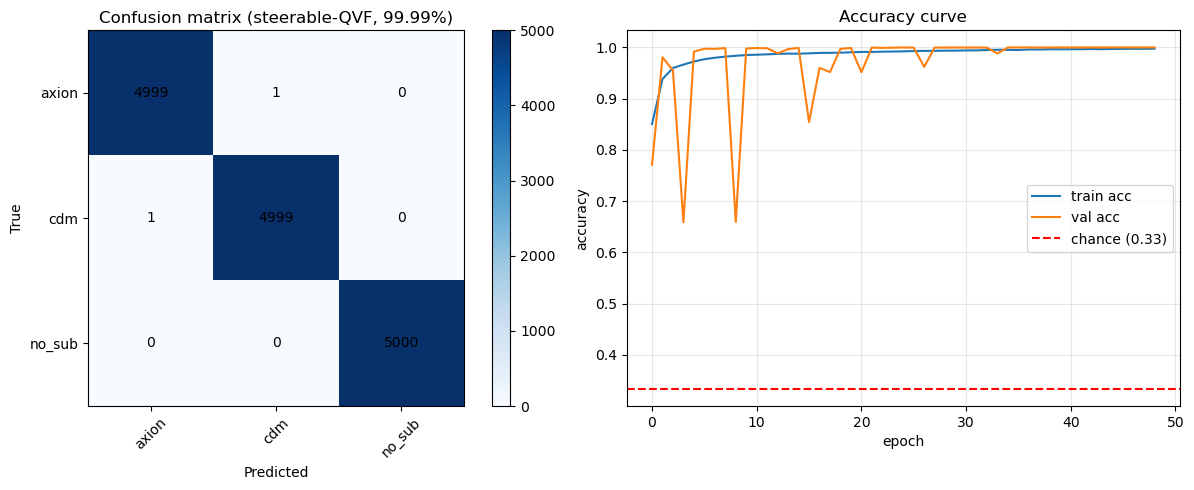

Saved metrics + figure to /home/jovyan/ssh-test-datavol-1/deeplense-quantum/notebooks/equivariant/steerable_qvf/model_2/results


In [9]:
# ---- Cell 8: Evaluate on the held-out test set ----

ckpt = torch.load(CHECKPOINT_PATH, map_location=device)
base_model.load_state_dict(ckpt["model_state"])   # load into the un-compiled module
model.eval()
print(f"Loaded best checkpoint (val_acc={ckpt['val_acc']:.4f}, epoch={ckpt['epoch']+1}).")

all_logits, all_labels = [], []
with torch.no_grad():
    for xb, yb in tqdm(test_loader, desc="test", leave=False):
        all_logits.append(model(xb.to(device)).cpu())
        all_labels.append(yb)

logits = torch.cat(all_logits).numpy()
labels = torch.cat(all_labels).numpy()
probs = torch.softmax(torch.from_numpy(logits), dim=1).numpy()
preds = probs.argmax(1)

test_acc = float((preds == labels).mean())
y_onehot = label_binarize(labels, classes=list(range(num_classes)))
try:
    macro_auc = roc_auc_score(y_onehot, probs, average="macro", multi_class="ovr")
except ValueError:
    macro_auc = float("nan")
macro_f1 = f1_score(labels, preds, average="macro")

print(f"Steerable-QVF QUANTUM model  ({n_total} trainable params: "
      f"{n_encoder} encoder + {n_quantum} quantum + {n_head} head)")
print(f"Test accuracy:      {test_acc:.4f}")
print(f"Test macro ROC-AUC: {macro_auc:.4f}")
print(f"Test macro F1:      {macro_f1:.4f}")
print("\nClassification report:")
print(classification_report(labels, preds, target_names=class_names, digits=4))

cm = confusion_matrix(labels, preds)
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
im = ax[0].imshow(cm, cmap="Blues")
ax[0].set_title(f"Confusion matrix (steerable-QVF, {test_acc*100:.2f}%)")
ax[0].set_xlabel("Predicted"); ax[0].set_ylabel("True")
ax[0].set_xticks(range(num_classes)); ax[0].set_xticklabels(class_names, rotation=45)
ax[0].set_yticks(range(num_classes)); ax[0].set_yticklabels(class_names)
for i in range(num_classes):
    for j in range(num_classes):
        ax[0].text(j, i, str(cm[i, j]), ha="center", va="center")
fig.colorbar(im, ax=ax[0], fraction=0.046)

ax[1].plot(history["train_acc"], label="train acc")
ax[1].plot(history["val_acc"], label="val acc")
ax[1].axhline(1.0 / num_classes, ls="--", c="red", label=f"chance ({1/num_classes:.2f})")
ax[1].set_title("Accuracy curve"); ax[1].set_xlabel("epoch"); ax[1].set_ylabel("accuracy")
ax[1].legend(); ax[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "steerable_qvf_test_summary.png", dpi=150, bbox_inches="tight")
plt.show()

with open(RESULTS_DIR / "steerable_qvf_metrics.json", "w") as f:
    json.dump({"test_acc": test_acc, "macro_auc": macro_auc, "macro_f1": macro_f1,
               "best_val_acc": best_val_acc, "total_params": n_total,
               "encoder_params": n_encoder, "quantum_params": n_quantum, "head_params": n_head,
               "group": f"{'D' if USE_REFLECTIONS else 'C'}{GROUP_N}",
               "classes": class_names}, f, indent=2)
print(f"Saved metrics + figure to {RESULTS_DIR}")